In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R
import random 

import time 

root_dir = os.path.abspath('..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.models.dpso_inference import DPSO

from src.data_loader.evaluation_data_generator import DataGenerator

from training.utils import pose_err


In [3]:
model_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/model.yaml'
sonar_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/sonar.yaml'

data_root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/train/seq_1'
data_output_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/training/test_output'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))

init_frames = model_config.TIME_WINDOW

from src.data_loader.transforms import SonarDatasetTranforms
data_generator = DataGenerator(data_root_dir, device, transforms = SonarDatasetTranforms)
data_lenght = data_generator.get_len()
print(f'Data generator initialized.')
print(f'Data series lenght: {data_lenght}')

Data generator initialized.
Data series lenght: 500


In [4]:
# init DPSO

ckpt_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/training/test_output/test_ckpt.ckpt'

model = DPSO(model_config_pth, sonar_config_pth, device, output_data_pth = data_output_dir)
model.load_state_dict(torch.load(ckpt_pth, weights_only=True))
model.eval()

DPSO(
  (PatchGraph): Graph(
    (patchifier): Patchifier(
      (feature_extractor): Encoder(
        (conv1): Conv2d(1, 32, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
        (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm1): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (ResBlock1): Sequential(
          (0): ResidualBlock(
            (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm1): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (norm2): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
          )
          (1): ResidualBlock(
            (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (conv2): Conv2d(32, 32, kernel_size=(3, 3), str

In [5]:

limit_frames = 20 

with torch.no_grad():

    for frame_idx in range(limit_frames):

        # t, frame, pose, frame_np = data_generator.get_sample(frame_idx, return_visu=True)
        
        t, frame, pose_gt = data_generator.get_sample(frame_idx, return_visu=False)
        
        if frame_idx <= init_frames:
            model.init_step(frame, t, pose_gt)
       
        else:
            n, t_, pose_pred = model(frame, t, debug_logger=False)

            translation_err, rot_err = pose_err(pose_pred.view(1, 1, 7), pose_gt.view(1, 1, 7))
            print(f'err: translation: {translation_err}, rotation: {rot_err}')

err: translation: 0.23775695264339447, rotation: 0.0594041608273983
err: translation: 0.571703314781189, rotation: 0.16708074510097504
err: translation: 0.8519525527954102, rotation: 0.24723252654075623
err: translation: 1.2830920219421387, rotation: 0.41959089040756226
err: translation: 1.7180482149124146, rotation: 0.5685710310935974
err: translation: 2.067201614379883, rotation: 0.7294585108757019
err: translation: 2.233473539352417, rotation: 0.8325718641281128
err: translation: 2.3521125316619873, rotation: 0.9253979325294495
err: translation: 2.4918696880340576, rotation: 1.023187518119812
err: translation: 2.6707687377929688, rotation: 1.099645972251892
err: translation: 2.9691169261932373, rotation: 1.2418153285980225
err: translation: 3.306945562362671, rotation: 1.379875659942627
err: translation: 3.5998125076293945, rotation: 1.5096226930618286
err: translation: 3.7200815677642822, rotation: 1.628483533859253
err: translation: 3.7309329509735107, rotation: 1.7180030345916748

In [9]:
prim_traj_pth = os.path.join(data_output_dir, 'prim_traj_estim.csv')
sec_traj_pth = os.path.join(data_output_dir, 'sec_traj_estim.csv')
pts_pth = os.path.join(data_output_dir, 'pts3d.csv')

data_generator.read_estim_trajectory(prim_traj_pth, 'primary estim traj')
data_generator.read_estim_trajectory(sec_traj_pth, 'secondary estim traj')
data_generator.read_pts(pts_pth)

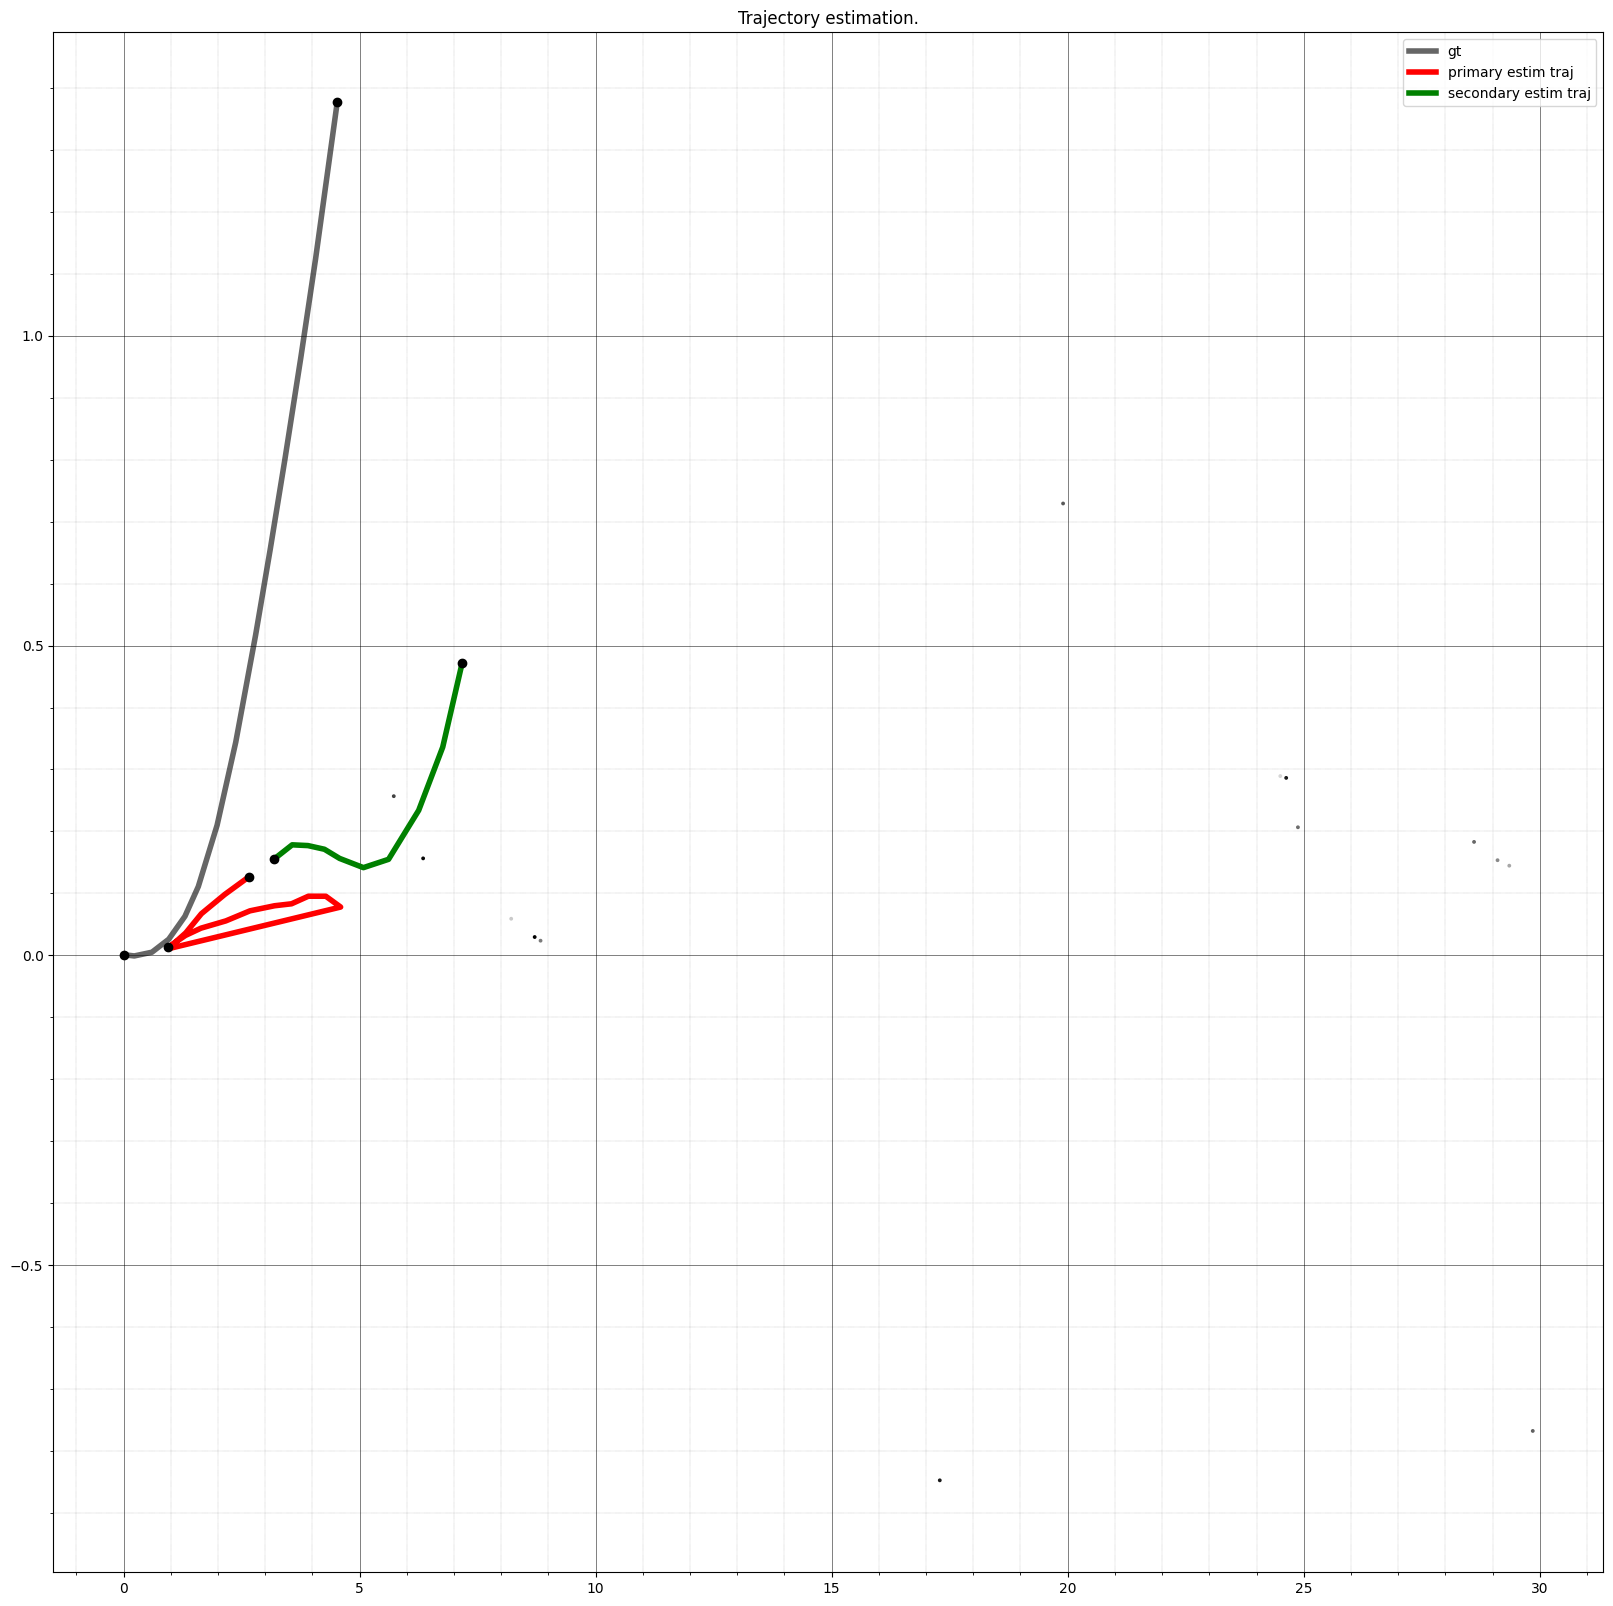

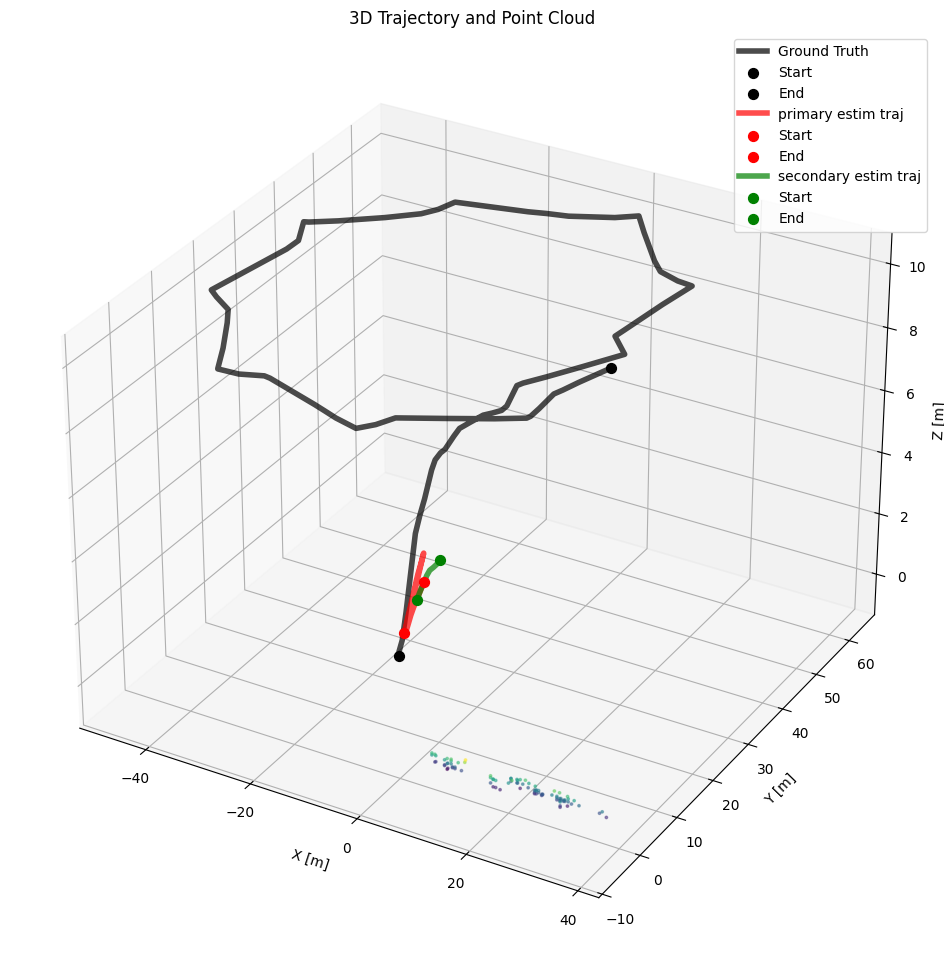

In [14]:
data_generator.generate_trajectory_map_2d(plane = 'xy', start = 0, end = 0.03)

data_generator.generate_trajectory_map_3d()
